In [6]:
import pandas as pd
import networkx as nx
import os

# 1. Percorsi e Caricamento
proc_path = os.path.join('..', 'data', 'processed')
nodes_cleaned = pd.read_csv(os.path.join(proc_path, 'nodes_cleaned.csv'))
edges_cleaned = pd.read_csv(os.path.join(proc_path, 'edges_cleaned.csv'))

# 2. Identificazione Seme Golden Power
seed_celex = '32019R0452'
seed_id = nodes_cleaned[nodes_cleaned['celex'] == seed_celex]['id'].values[0]

# 3. Estrazione dei vicini (Rete Golden Power)
connections = edges_cleaned[(edges_cleaned['source'] == seed_id) | (edges_cleaned['target'] == seed_id)]
neighbor_ids = set(connections['source']) | set(connections['target'])
network_data = nodes_cleaned[nodes_cleaned['id'].isin(neighbor_ids)]

# 4. Creazione dell'oggetto G (quello che dava NameError)
G = nx.Graph()
for _, row in network_data.iterrows():
    G.add_node(row['id'], title=row['work_title'], celex=row['celex'])

for _, row in connections.iterrows():
    if row['source'] in G.nodes and row['target'] in G.nodes:
        G.add_edge(row['source'], row['target'])

# 5. Calcolo delle posizioni (pos)
pos = nx.spring_layout(G, k=0.5, seed=42)

print(f"Grafo 'G' ricostruito con {G.number_of_nodes()} nodi e {G.number_of_edges()} archi.")

Grafo 'G' ricostruito con 39 nodi e 38 archi.


In [9]:
# Il CELEX del Regolamento Golden Power (UE 2019/452)
seed_celex = '32019R0452'

# 1. Trova l'ID interno del seme
seed_node = nodes_cleaned[nodes_cleaned['celex'] == seed_celex]
if seed_node.empty:
    print(f"Errore: CELEX {seed_celex} non trovato!")
else:
    seed_id = seed_node.iloc[0]['id']
    
    # 2. Trova i vicini (chi cita il seme e chi è citato dal seme)
    # Incoming: leggi che citano la Golden Power
    # Outgoing: leggi citate dalla Golden Power (basi legali)
    connections = edges_cleaned[(edges_cleaned['source'] == seed_id) | (edges_cleaned['target'] == seed_id)]
    
    # Otteniamo tutti gli ID dei nodi connessi
    neighbor_ids = set(connections['source']) | set(connections['target'])
    
    # 3. Estrai i dettagli di queste leggi
    golden_power_network = nodes_cleaned[nodes_cleaned['id'].isin(neighbor_ids)]
    
    print(f"Trovate {len(golden_power_network)} leggi connesse alla Golden Power.")

Trovate 39 leggi connesse alla Golden Power.


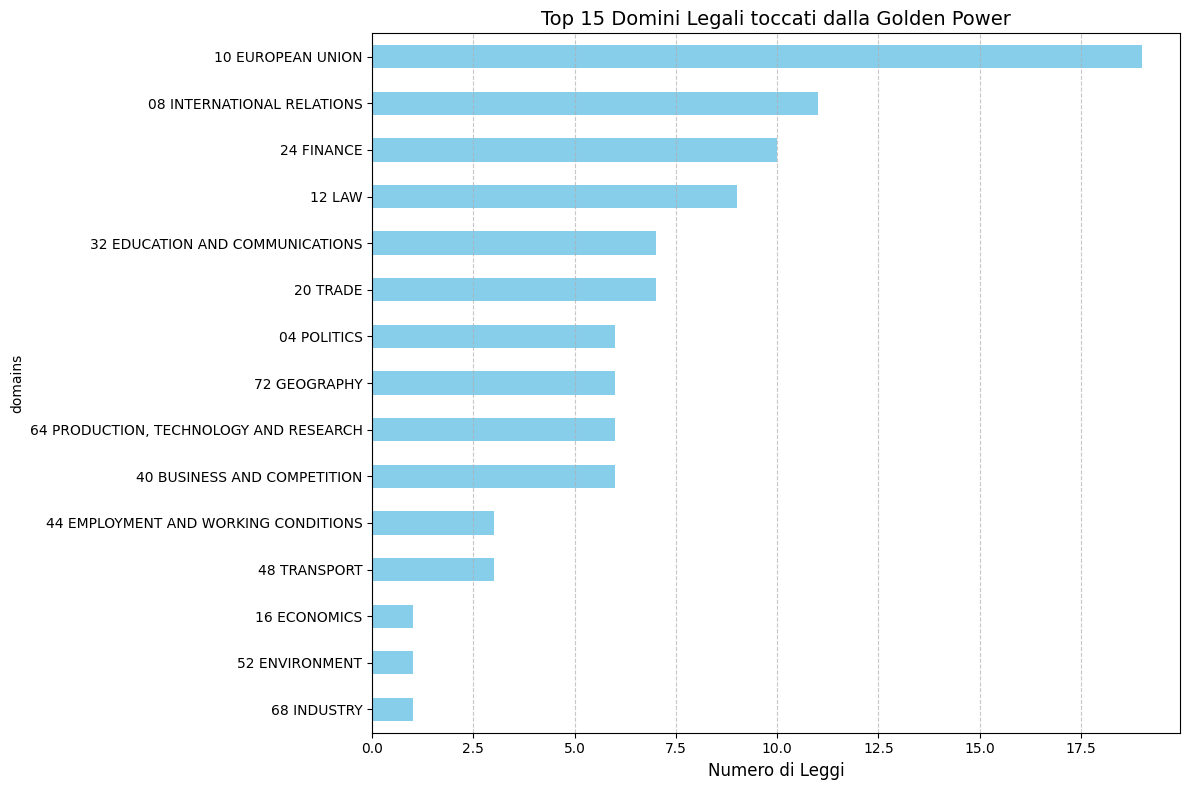

In [10]:
# 1. Rompiamo le stringhe in liste e "esplodiamole"
# Trasformiamo 'A;B;C' in tre righe distinte: A, B e C
domains_exploded = golden_power_network['domains'].dropna().str.split(';').explode()

# 2. Puliamo eventuali spazi bianchi ai bordi
domains_exploded = domains_exploded.str.strip()

# 3. Contiamo le occorrenze dei singoli domini
clean_domain_counts = domains_exploded.value_counts()

# 4. Creiamo un grafico molto più chiaro
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
clean_domain_counts.head(15).plot(kind='barh', color='skyblue') # Usiamo barre orizzontali per leggere meglio i nomi
plt.title("Top 15 Domini Legali toccati dalla Golden Power", fontsize=14)
plt.xlabel("Numero di Leggi", fontsize=12)
plt.gca().invert_yaxis() # Mette il più frequente in alto
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
import plotly.graph_objects as go
import plotly.express as px # Per scale di colori qualitative

# 1. Prepariamo i colori per i domini
# Estraiamo il primo ID di dominio per ogni nodo
node_colors = []
for node in G.nodes():
    # Recuperiamo il dominio salvato nel nodo (assicurati che sia presente)
    # Se non c'è, cerchiamolo in network_data
    dom_string = network_data[network_data['id'] == node]['domains'].values[0]
    
    if isinstance(dom_string, str):
        # Prendiamo i primi due numeri (ID del dominio)
        dom_id = dom_string.split(' ')[0]
        try:
            node_colors.append(int(dom_id))
        except:
            node_colors.append(0) # Default se non è un numero
    else:
        node_colors.append(0)

# 2. Traccia degli ARCHI (resta uguale)
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=0.5, color='#888'), hoverinfo='none', mode='lines')

# 3. Traccia dei NODI (con colori tematici)
node_x, node_y, node_text = [], [], []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    
    celex = G.nodes[node].get('celex', 'N/A')
    title = G.nodes[node].get('title', 'N/A')
    dom = network_data[network_data['id'] == node]['domains'].values[0]
    if not isinstance(title, str): title = "N/A"
    
    node_text.append(f"CELEX: {celex}<br>Dominio: {dom}<br>{title[:60]}...")

node_trace = go.Scatter(
    x=node_x, y=node_y, mode='markers', hoverinfo='text', text=node_text,
    marker=dict(
        showscale=True,
        colorscale='Rainbow', # Scala molto contrastata per vedere i diversi temi
        size=14,
        line_width=2,
        color=node_colors, # Qui usiamo l'ID del dominio (10, 08, 24...)
        colorbar=dict(
            thickness=15,
            title=dict(text='ID Dominio EuroVoc', side='right'),
            xanchor='left'
        )
    )
)

# 4. Creazione FIGURA
fig_thematic = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title=dict(text='Frammentazione Tematica Golden Power (Colore = Dominio)', font=dict(size=16)),
                showlegend=False, hovermode='closest', margin=dict(b=20,l=5,r=5,t=40),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )

fig_thematic.show()

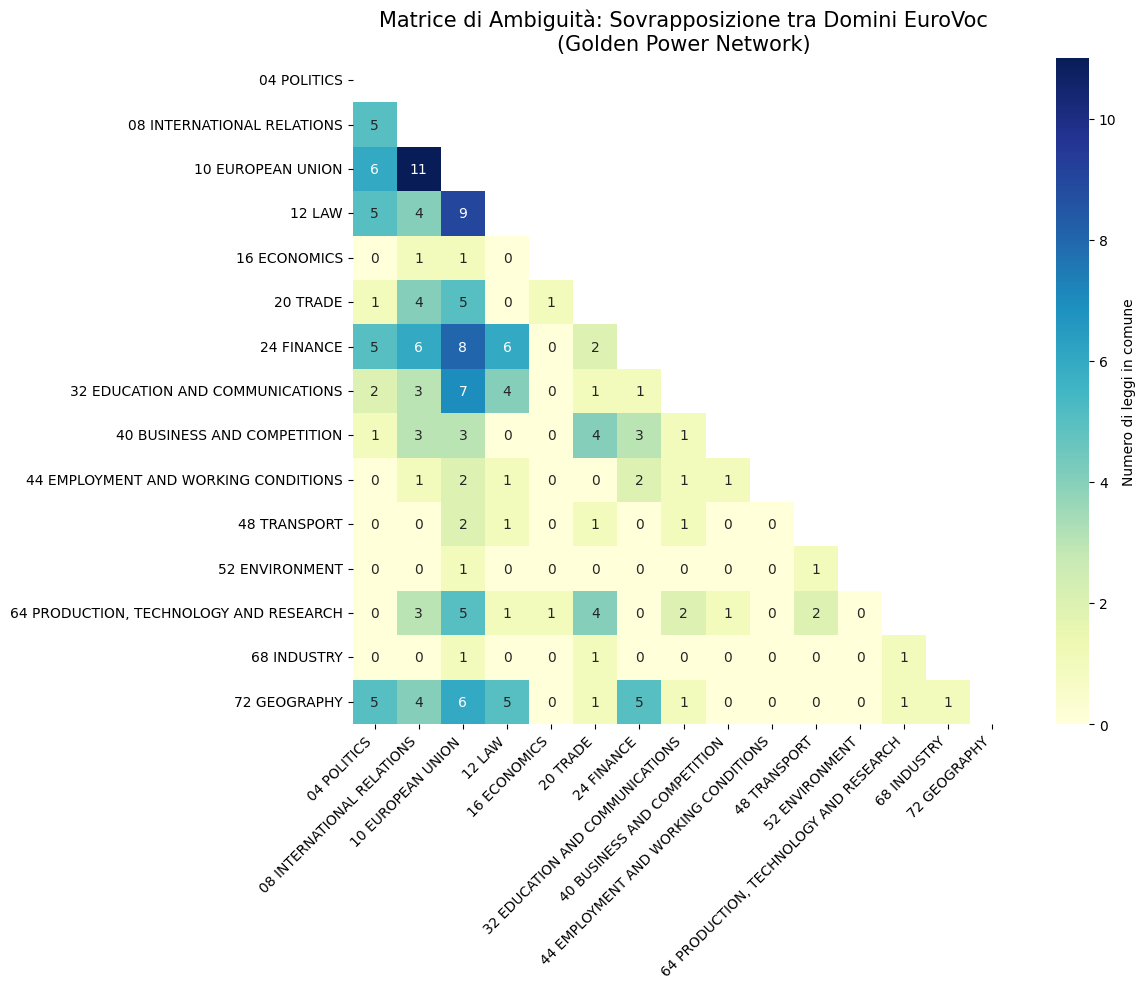

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from collections import Counter

# 1. Pulizia e preparazione dei dati
# Prendiamo la colonna dei domini e rimuoviamo i valori mancanti (NaN)
dom_series = network_data['domains'].dropna()

# Funzione per estrarre solo i nomi dei domini puliti
def get_domain_list(text):
    # Separiamo per ';' e puliamo gli spazi
    parts = [p.strip() for p in text.split(';')]
    # Teniamo solo il nome o l'ID per brevità (es. "10 EUROPEAN UNION")
    return parts

# 2. Calcolo delle Co-occorrenze
pair_counts = Counter()
all_domains = set()

for entry in dom_series:
    domains = get_domain_list(entry)
    all_domains.update(domains)
    # Creiamo tutte le possibili coppie di domini presenti nella stessa legge
    for pair in combinations(sorted(domains), 2):
        pair_counts[pair] += 1

# 3. Creazione della Matrice
unique_domains = sorted(list(all_domains))
# Limitiamo ai top 15 domini più frequenti per leggibilità
top_domains = network_data['domains'].str.split(';').explode().str.strip().value_counts().head(15).index.tolist()
unique_domains = sorted(top_domains)

matrix = pd.DataFrame(0, index=unique_domains, columns=unique_domains)

for (d1, d2), count in pair_counts.items():
    if d1 in unique_domains and d2 in unique_domains:
        matrix.loc[d1, d2] = count
        matrix.loc[d2, d1] = count # La matrice è simmetrica

# 4. Visualizzazione con Seaborn
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(matrix, dtype=bool)) # Nascondiamo la metà superiore per pulizia

sns.heatmap(matrix, mask=mask, annot=True, fmt='d', cmap='YlGnBu', 
            cbar_kws={'label': 'Numero di leggi in comune'})

plt.title('Matrice di Ambiguità: Sovrapposizione tra Domini EuroVoc\n(Golden Power Network)', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Salvataggio per la tesi
plt.savefig('../results/co_occurrence_matrix.png')
plt.show()